In [2]:
import urllib.request; exec(urllib.request.urlopen('https://aic-data.aiffel.io/api/colab/setup?t=3vvc47bz').read().decode())

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit



⏳  터널 준비 확인 중...

✅  터널 생성 완료!
🔗  URL: https://practices-essex-wolf-incentive.trycloudflare.com

아래 [URL 복사] 버튼을 누른 뒤 웹앱 연결창에 붙여넣으세요. (이 탭은 열어두세요)


✅ 웹앱에 자동 연결 요청을 보냈습니다. 잠시 후 웹앱 화면이 연결됩니다.


In [10]:
# ─────────────────────────────────────────────
# 통합 환경 준비 — 라이브러리 + 한글 폰트 강제 주입 + 출력 최적화
# ─────────────────────────────────────────────
# 1. 필요 패키지 설치 및 인라인 렌더링 선언
!pip install missingno plotly -q
!apt-get -y install fonts-nanum -q
%matplotlib inline

import platform
import warnings
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import missingno as msno

import plotly.express as px
import plotly.io as pio

# 2. 경고 무시 및 시드 고정
warnings.filterwarnings("ignore")
np.random.seed(42)

# 3. 코랩(Linux) 환경일 때 캐시를 무시하는 0순위 폰트 강제 주입
if platform.system() == "Linux":
    nanum_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    if os.path.exists(nanum_path):
        # fontpath -> fname 으로 매개변수명 수정
        fe = fm.FontEntry(fname=nanum_path, name='NanumGothic_Force')
        fm.fontManager.ttflist.insert(0, fe)
        font_family = 'NanumGothic_Force'
else:
    # 맥/윈도우 로컬 환경일 때 분기
    system = platform.system()
    font_family = "AppleGothic" if system == "Darwin" else "Malgun Gothic"

# 4. Matplotlib / Seaborn 전역 폰트 및 그래픽 설정
plt.rcParams["font.family"] = font_family
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지
plt.rcParams["figure.figsize"] = (10, 5)     # 차트 기본 크기
plt.rcParams["figure.dpi"] = 100            # 글자 선명도 향상

sns.set_style("whitegrid")
sns.set(font=font_family, rc={'axes.unicode_minus': False}, style='whitegrid')

# 5. 코랩 전용 출력 최적화 (인터랙티브 표 및 Plotly 렌더러)
try:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()
except ImportError:
    pass

try:
    pio.renderers.default = "colab"
except Exception:
    pass

print(f"준비 완료! [적용된 폰트: {font_family}]")

Reading package lists...

INFO:werkzeug:127.0.0.1 - - [20/Jul/2026 06:53:07] "OPTIONS /ping HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [20/Jul/2026 06:53:08] "GET /ping HTTP/1.1" 200 -



Building dependency tree...
Reading state information...
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
준비 완료! [적용된 폰트: NanumGothic_Force]


In [12]:
# ─────────────────────────────────────────────
# 모두마켓 데이터 생성 — 정제 전(raw)과 정제 후(clean) 두 버전
# ─────────────────────────────────────────────
np.random.seed(42)

# 1) 고객
n_customers = 500
customers = pd.DataFrame({
    "customer_id": [f"C{str(i).zfill(4)}" for i in range(1, n_customers + 1)],
    "age": np.random.normal(35, 9, n_customers).round().astype(int),
    "gender": np.random.choice(["M", "F"], n_customers),
    "region": np.random.choice(["서울", "경기", "부산", "인천", "대구"], n_customers),
    "membership": np.random.choice(["basic", "premium", "vip"], n_customers, p=[0.6, 0.3, 0.1]),
})
# 일부러 심은 오염
customers.loc[5, "age"] = 999
customers.loc[10, "age"] = -3
customers.loc[[20, 21, 22, 23], "gender"] = np.nan
customers.loc[30, "region"] = " 서울 "

# 2) 상품
categories = ["패션", "뷰티", "식품", "가전", "도서"]
products = pd.DataFrame({
    "product_id": [f"P{str(i).zfill(3)}" for i in range(1, 41)],
    "category": np.random.choice(categories, 40),
    "price": np.random.choice([9900, 19900, 29900, 49900, 89900, 129900], 40),
})

# 3) 주문 — 정제 전 버전
n_orders = 3000
order_customer = np.random.choice(customers["customer_id"], n_orders)
order_product = np.random.choice(products["product_id"], n_orders)
price_map = products.set_index("product_id")["price"]
quantity = np.random.choice([1, 1, 1, 2, 2, 3], n_orders)
amount = price_map.loc[order_product].values * quantity

orders_raw = pd.DataFrame({
    "order_id": [f"O{str(i).zfill(5)}" for i in range(1, n_orders + 1)],
    "customer_id": order_customer,
    "product_id": order_product,
    "quantity": quantity.astype(float),
    "amount": amount.astype(float),
    "channel": np.random.choice(["web", "app", "app ", "APP"], n_orders, p=[0.45, 0.45, 0.05, 0.05]),
})

# 의도적 오염: amount의 일부는 결측(특히 web 채널에서 더 자주 결측 — MAR 패턴)
web_mask = orders_raw["channel"] == "web"
web_idx = orders_raw[web_mask].sample(150, random_state=1).index
other_idx = orders_raw[~web_mask].sample(40, random_state=1).index
orders_raw.loc[web_idx, "amount"] = np.nan
orders_raw.loc[other_idx, "amount"] = np.nan

# quantity 이상치
orders_raw.loc[7, "quantity"] = 100
orders_raw.loc[123, "quantity"] = 80

# amount 이상치(VIP 한 명의 대량 구매)
orders_raw.loc[200, "amount"] = 5_000_000

# 중복 행
orders_raw = pd.concat([orders_raw, orders_raw.iloc[[0, 1, 2]]], ignore_index=True)

# 날짜 — 일부 포맷 혼재
base_dates = pd.to_datetime("2025-01-01") + pd.to_timedelta(
    np.random.randint(0, 120, len(orders_raw)), unit="D"
)
orders_raw["order_date"] = base_dates

# 4) 정제 후 버전 — D+003~D+007에서 배운 기법을 적용했다고 가정
orders_clean = orders_raw.copy()
# (a) 중복 제거
orders_clean = orders_clean.drop_duplicates(subset="order_id").reset_index(drop=True)
# (b) channel 표기 통일
orders_clean["channel"] = orders_clean["channel"].str.strip().str.lower()
# (c) quantity 이상치를 IQR 기준 상한으로 클리핑
q1, q3 = orders_clean["quantity"].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
orders_clean.loc[orders_clean["quantity"] > upper, "quantity"] = upper
# (d) amount 결측은 'product_id 평균 단가 × 수량'으로 대체
mean_unit_price = (orders_clean.dropna(subset=["amount"])
                   .assign(unit=lambda d: d["amount"] / d["quantity"])
                   .groupby("product_id")["unit"].mean())
need_fill = orders_clean["amount"].isna()
orders_clean.loc[need_fill, "amount"] = (
    orders_clean.loc[need_fill, "product_id"].map(mean_unit_price)
    * orders_clean.loc[need_fill, "quantity"]
)
# (e) amount 극단 이상치도 99% 분위수로 클리핑
cap = orders_clean["amount"].quantile(0.99)
orders_clean.loc[orders_clean["amount"] > cap, "amount"] = cap

print("정제 전 :", orders_raw.shape, "결측 amount:", orders_raw["amount"].isna().sum())
print("정제 후 :", orders_clean.shape, "결측 amount:", orders_clean["amount"].isna().sum())

정제 전 : (3003, 7) 결측 amount: 189
정제 후 : (3000, 7) 결측 amount: 0


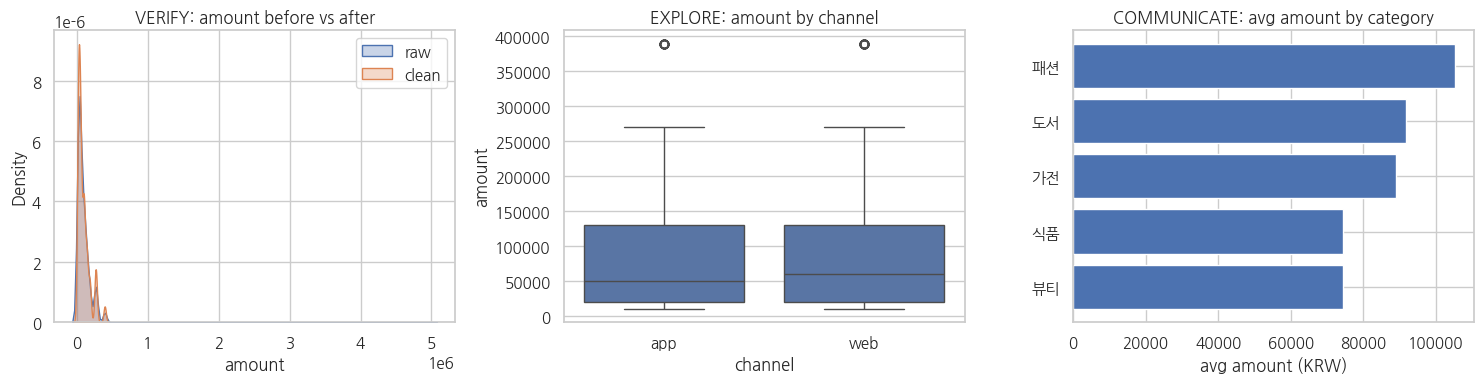

In [13]:
# 같은 데이터, 다른 목적 — 세 가지 그림으로 보여주기 (맛보기)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (검증) 정제 전·후 amount 분포 겹쳐 그리기
sns.kdeplot(orders_raw["amount"].dropna(), ax=axes[0], label="raw", fill=True, alpha=0.3)
sns.kdeplot(orders_clean["amount"], ax=axes[0], label="clean", fill=True, alpha=0.3)
axes[0].set_title("VERIFY: amount before vs after")
axes[0].legend()

# (탐색) channel별 amount 박스 — 어떤 채널이 큰 금액?
sns.boxplot(data=orders_clean, x="channel", y="amount", ax=axes[1])
axes[1].set_title("EXPLORE: amount by channel")

# (전달) 카테고리별 평균 매출 — 한 메시지
cat_sales = (orders_clean.merge(products, on="product_id")
             .groupby("category")["amount"].mean().sort_values())
axes[2].barh(cat_sales.index, cat_sales.values, color="#4C72B0")
axes[2].set_title("COMMUNICATE: avg amount by category")
axes[2].set_xlabel("avg amount (KRW)")

plt.tight_layout(); plt.show()

# 스스로 해보자! (1) — 머릿속으로 답한 뒤 아래 한 줄에 적어보세요.
## 1) 검증
## 2) 탐색
## 3) 전달

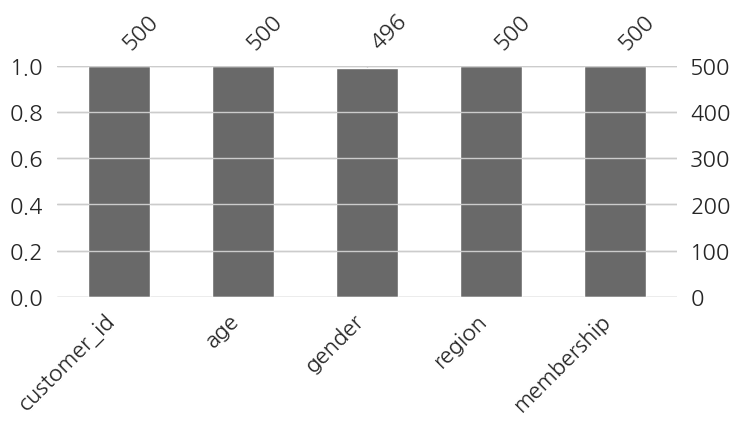

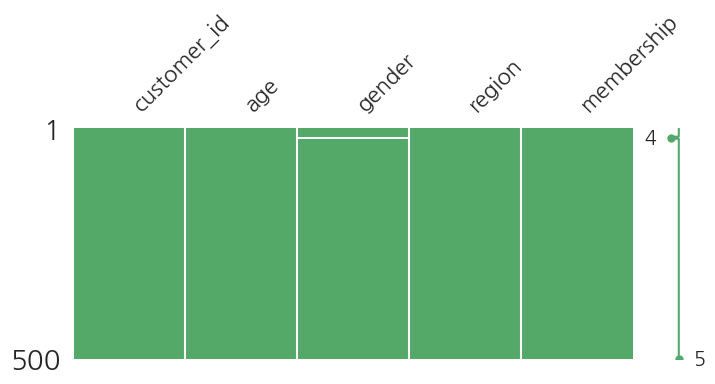

In [16]:
# 스스로 해보자! (2)
# 1) customers에 missingno bar / matrix 그리기
msno.bar(customers, figsize=(8, 3)); plt.show()
msno.matrix(customers, color=(0.33, 0.66, 0.41), figsize=(8, 3)); plt.show()

In [17]:
# 탐색을 위해 clean 데이터에 customer/product 정보를 합쳐 둡니다.
# (병합 자체는 D+004의 주제. 여기선 결과만 활용합니다.)
df = (orders_clean
      .merge(customers[["customer_id", "age", "gender", "region", "membership"]], on="customer_id", how="left")
      .merge(products[["product_id", "category", "price"]], on="product_id", how="left"))
# 나이 이상치(999, -3)는 분석 전 제거
df = df[df["age"].between(15, 80)].copy()

print("탐색용 df 모양:", df.shape)
df.head(3)

탐색용 df 모양: (2979, 13)


,order_id,customer_id,product_id,quantity,amount,channel,order_date,age,gender,region,membership,category,price
0,O00001,C0149,P018,1.0,49900.0,app,2025-03-08,40,M,경기,basic,식품,49900
1,O00002,C0126,P002,1.0,49900.0,web,2025-03-07,55,F,대구,basic,식품,49900
2,O00003,C0392,P008,2.0,99800.0,web,2025-02-21,39,F,경기,basic,도서,49900


In [18]:
# 1) 인터랙티브 산점도 — hover에 고객 정보까지
sample = df.sample(800, random_state=42)
fig = px.scatter(
    sample, x="age", y="amount",
    color="membership",
    size="quantity", size_max=15,
    hover_data=["customer_id", "region", "category"],
    title="Age vs Amount (interactive) — hover/zoom/filter",
)
fig.update_layout(width=900, height=500)
fig.show()

In [19]:
# 2) 시간 추이 — 일자별 매출 추이 (인터랙티브 line)
daily = (df.assign(day=df["order_date"].dt.date)
           .groupby("day")["amount"].sum().reset_index())
fig = px.line(daily, x="day", y="amount",
              title="Daily total amount (interactive)",
              markers=True)
fig.update_layout(width=900, height=400)
fig.show()

In [20]:
# 3) 비교 — 카테고리·멤버십 교차 막대 (barmode='group')
grouped = (df.groupby(["category", "membership"])["amount"].sum().reset_index())

fig = px.bar(grouped, x="category", y="amount", color="membership",
             barmode="group",
             category_orders={"membership": ["basic", "premium", "vip"]},
             title="Total amount by category × membership (interactive)")
fig.update_layout(width=900, height=450)
fig.show()

In [21]:
# 스스로 해보자! (5)
fig = px.histogram(df, x="amount", color="membership",
                   barmode="overlay", opacity=0.5,
                   title="Amount distribution by membership")
fig.update_layout(width=900, height=400); fig.show()

In [22]:
# ─────────────────────────────────────────────
# 모두마켓 웹 접속 로그(가상) — 일부러 오염을 심어 둡니다.
# ─────────────────────────────────────────────
np.random.seed(7)
n_log = 2500
logs_raw = pd.DataFrame({
    "log_id":           [f"L{str(i).zfill(6)}" for i in range(1, n_log + 1)],
    "session_id":       np.random.choice([f"S{str(i).zfill(4)}" for i in range(1, 401)], n_log),
    "response_time_ms": np.abs(np.random.normal(180, 80, n_log)).round(0),
    "request_path":     np.random.choice(["/home", "/category", "/product", "/cart", "/checkout"], n_log,
                                         p=[0.35, 0.2, 0.25, 0.1, 0.1]),
    "device":           np.random.choice(["mobile", "Mobile", "MOBILE", "desktop", "DESKTOP"], n_log,
                                         p=[0.35, 0.15, 0.2, 0.2, 0.1]),
    "hour":             np.random.randint(0, 24, n_log),
    "is_error":         np.random.choice([0, 1], n_log, p=[0.97, 0.03]),
})
# 의도적 오염
# (a) response_time_ms 결측 (심야 시간대에 많이 — 측정 모듈 점검 시간) — MAR 패턴
night = logs_raw["hour"].isin([2, 3, 4])
night_idx = logs_raw[night].sample(min(80, night.sum()), random_state=1).index
day_idx = logs_raw[~night].sample(40, random_state=1).index
logs_raw.loc[night_idx, "response_time_ms"] = np.nan
logs_raw.loc[day_idx, "response_time_ms"] = np.nan
# (b) response_time_ms 이상치 (네트워크 정체로 60초·45초 지연된 응답)
logs_raw.loc[5, "response_time_ms"] = 60_000
logs_raw.loc[6, "response_time_ms"] = 45_000
# (c) hour 이상치 (잘못된 값)
logs_raw.loc[100, "hour"] = 99
# (d) 중복
logs_raw = pd.concat([logs_raw, logs_raw.iloc[[0, 1]]], ignore_index=True)

print("웹 로그 준비:", logs_raw.shape, "| 결측 response_time_ms:", logs_raw["response_time_ms"].isna().sum())
logs_raw.head(3)

웹 로그 준비: (2502, 7) | 결측 response_time_ms: 120


,log_id,session_id,response_time_ms,request_path,device,hour,is_error
0,L000001,S0176,275.0,/home,Mobile,23,0
1,L000002,S0197,217.0,/category,mobile,8,0
2,L000003,S0026,85.0,/home,desktop,6,0


In [24]:
# 시나리오 2 — 정제
logs_clean = logs_raw.drop_duplicates(subset="log_id").reset_index(drop=True)
# device 표기 통일 (대소문자 혼재)
device_map = {"mobile": "mobile", "Mobile": "mobile", "MOBILE": "mobile",
              "desktop": "desktop", "DESKTOP": "desktop"}
logs_clean["device"] = logs_clean["device"].map(device_map)
# hour 이상치 제거 (사실 0~23 외는 모두 이상)
logs_clean = logs_clean[logs_clean["hour"].between(0, 23)].copy()
# response_time_ms 결측 — 요청 경로별 중앙값으로 대체
medians = logs_clean.groupby("request_path")["response_time_ms"].median()
need = logs_clean["response_time_ms"].isna()
logs_clean.loc[need, "response_time_ms"] = logs_clean.loc[need, "request_path"].map(medians)
# response_time_ms 클리핑 (p99)
cap = logs_clean["response_time_ms"].quantile(0.99)
logs_clean.loc[logs_clean["response_time_ms"] > cap, "response_time_ms"] = cap

print("clean 모양:", logs_clean.shape, "| 결측 response_time_ms:", logs_clean["response_time_ms"].isna().sum())

clean 모양: (2499, 7) | 결측 response_time_ms: 0


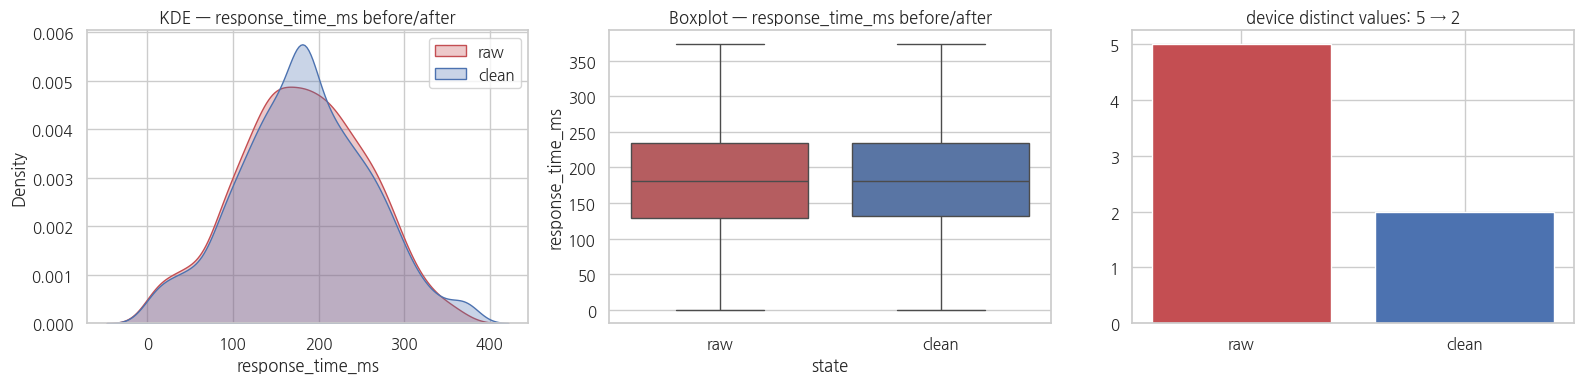

In [27]:
# 검증 — 전후 분포 비교 (3종 세트)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) KDE 겹쳐
raw_rt = logs_raw["response_time_ms"].dropna()
raw_rt = raw_rt[raw_rt <= cap]
sns.kdeplot(raw_rt, label="raw", color="#C44E52", fill=True, alpha=0.3, ax=axes[0])
sns.kdeplot(logs_clean["response_time_ms"], label="clean", color="#4C72B0", fill=True, alpha=0.3, ax=axes[0])
axes[0].set_title("KDE — response_time_ms before/after"); axes[0].legend()

# (b) 박스 side-by-side
long_rt = pd.concat([
    pd.DataFrame({"response_time_ms": raw_rt.values, "state": "raw"}),
    pd.DataFrame({"response_time_ms": logs_clean["response_time_ms"].values, "state": "clean"}),
])
sns.boxplot(data=long_rt, x="state", y="response_time_ms",
            order=["raw", "clean"], ax=axes[1], palette=["#C44E52", "#4C72B0"])
axes[1].set_title("Boxplot — response_time_ms before/after")

# (c) device 정제 검증
raw_dev_n = logs_raw["device"].nunique()
cln_dev_n = logs_clean["device"].nunique()
axes[2].bar(["raw", "clean"], [raw_dev_n, cln_dev_n], color=["#C44E52", "#4C72B0"])
axes[2].set_title(f"device distinct values: {raw_dev_n} → {cln_dev_n}")

plt.tight_layout(); plt.show()

/category 상한선: 366.5 이상치 개수: 6
[374.02 374.   374.   374.02 369.   374.02]
/cart 상한선: 358.5 이상치 개수: 3
[362.   374.02 374.02]


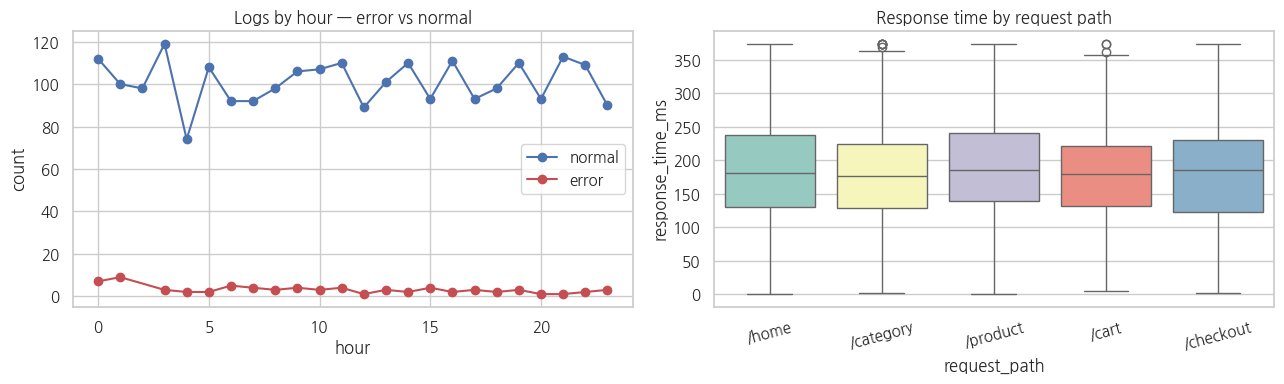

In [28]:
# 시나리오 3 — 탐색
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# (a) 시간대별 로그 수 — 에러 vs 정상 비교
hour_err = logs_clean.groupby(["hour", "is_error"]).size().reset_index(name="n")
for label, color in [(0, "#4C72B0"), (1, "#C44E52")]:
    part = hour_err[hour_err["is_error"] == label]
    axes[0].plot(part["hour"], part["n"], marker="o",
                 label="normal" if label == 0 else "error", color=color)
axes[0].set_title("Logs by hour — error vs normal")
axes[0].set_xlabel("hour"); axes[0].set_ylabel("count"); axes[0].legend()

# (b) 요청 경로별 응답 시간 분포
sns.boxplot(data=logs_clean, x="request_path", y="response_time_ms",
            order=["/home", "/category", "/product", "/cart", "/checkout"],
            ax=axes[1], palette="Set3")
axes[1].set_title("Response time by request path")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout(); plt.show()

for path in ["/category", "/cart"]:
    sub = logs_clean[logs_clean["request_path"] == path]["response_time_ms"]
    q1, q3 = sub.quantile(0.25), sub.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    outliers = sub[sub > upper]
    print(path, "상한선:", upper, "이상치 개수:", len(outliers))
    print(outliers.values)

In [25]:
# 시나리오 4 — 전달용 인터랙티브 차트
err_hour = (logs_clean.groupby(["hour", "is_error"]).size()
            .reset_index(name="count"))
err_hour["is_error"] = err_hour["is_error"].map({0: "normal", 1: "error"})

fig = px.bar(err_hour, x="hour", y="count", color="is_error",
             barmode="group", title="Hourly logs — error vs normal",
             color_discrete_map={"normal": "#4C72B0", "error": "#C44E52"})
fig.update_layout(width=900, height=420)
fig.show()

In [26]:
# 코드 퀴즈 — 모범 답안
joined = (orders_clean
          .merge(customers[["customer_id", "membership"]], on="customer_id")
          .merge(products[["product_id", "category"]], on="product_id"))
mean_amt = joined.groupby(["category", "membership"])["amount"].mean().reset_index()

fig = px.bar(mean_amt, x="category", y="amount", color="membership",
             barmode="group",
             category_orders={"membership": ["basic", "premium", "vip"]},
             title="Average amount by category × membership")
fig.update_layout(width=900, height=420)
fig.show()

# 모두마켓 웹 접속 로그 — EDA & 시각화 보고서

## 1. 데이터 개요
- 행/열: (2502행, 7열)
- 주요 컬럼: log_id, session_id, response_time_ms, request_path, device, hour, is_error

## 2. 결측 진단 (missingno)
- `response_time_ms` 결측 비율: 4.8 %
- 결측 패턴: 0시 부근에서 조금 더 많이 관찰됨
- 의심 가설: 0시 부근 cron 작업 또는 점검과 관련이 있는지 살펴볼 필요성이 있음.

## 3. 정제와 검증 (전·후 분포 비교)
- 적용한 정제: 중복 제거 / device 표기 통일 / hour 이상치 / response_time_ms 결측 대체 / 극단치 클리핑
- KDE 비교 결과: (본질이 유지됨 / 한쪽이 좁아짐 등)
- device distinct: 5 → 2 (정상)
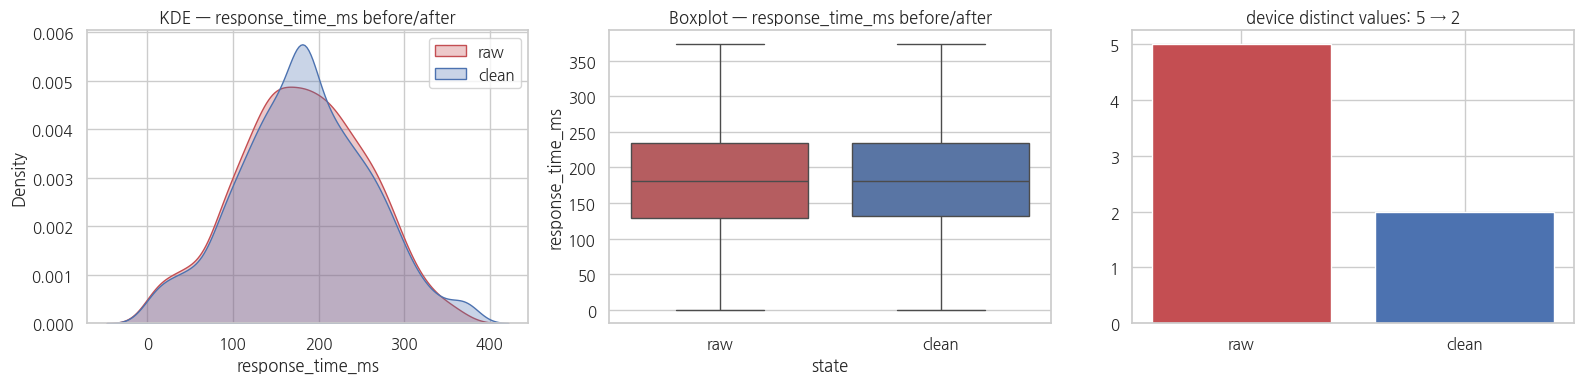

## 4. 탐색에서 도출한 새 질문
home 화면과 product 화면이 응답시간이 미세하게 더 오래 걸리는 것 같다.
많은 상품을 로딩해야 되므로 다른 페이지에 비해 로딩이 길어지는 것으로 판단됨.
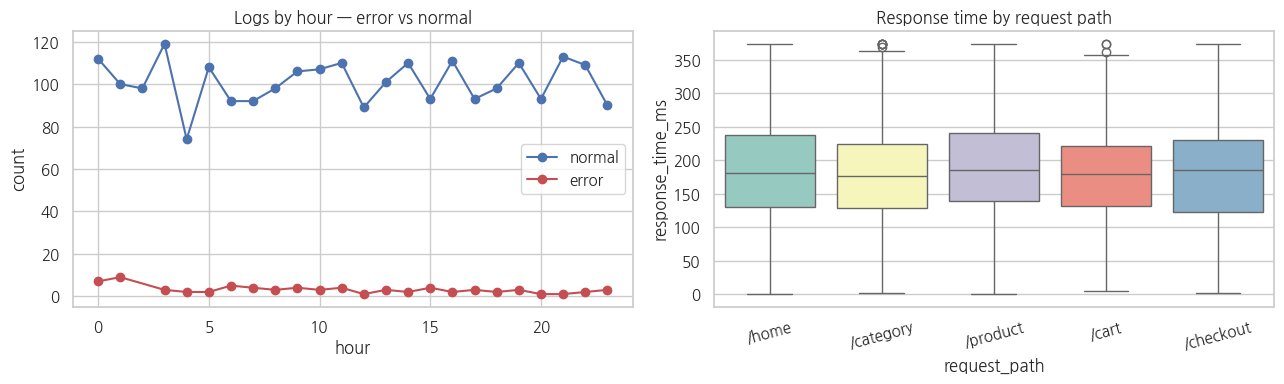

## 5. 전달용 차트 1개
- 에러는 0 ~ 1시 부근이 많음. 웹서버 설정을 참조하여 그 시간대에 주기적 작업(cronjob 등)이 실행되도록 설정되어 있는지 살펴봐야 함.
- 4번 섹션의 그래프를 보면 category, cart 에서 몇 건의 3초 이상의 느린 응답이 발견됨.
- category 페이지 응답시간 상한선: 366.5 이상치 개수: 6
[374.02 374.   374.   374.02 369.   374.02]
- cart 페이지 응답시간 상한선: 358.5 이상치 개수: 3
[362.   374.02 374.02]

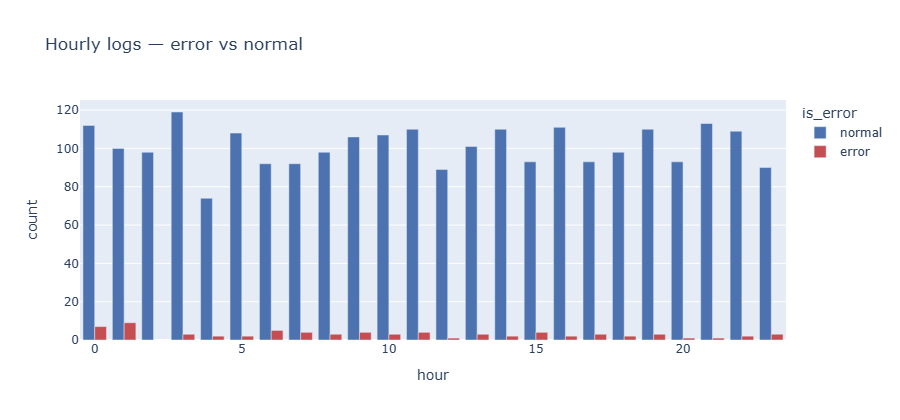

## 6. 다음 분석 제안
- 에러 응답 원인 추척: 웹서버 cronjob 점검.
- 디바이스별로 응답시간 및 에러가 다르게 나올 가능성 점검
- category, cart 의 응답시간 이상치 몇 건은 로직 상의 문제인지 점검
- home, product 페이지가 다른 페이지 보다 응답시간이 조금 더 걸리는 문제가, 상품 테이블을 가져오면서 생긴 문제인지 점검.
- home 화면에서는 보통 많은 상품, 히트 상품을 나열. 부하 점검.
- product 화면에서는 해당 상품과 비슷한 다른 추천 상품을 SQL 조인으로 표현하면서 부하가 걸린 것인지 점검